# Full-versus-partial AIT best-direction cosine alignment

This read-only exploration compares the frozen best-layer **mean-difference** and **one-dimensional DAS** directions from two AIT last-token experiments:

- partial AIT: `ait-last-token-directions/runs/2026-09-23_02-47_CDT`;
- full AIT: `full-ait-last-token-directions/runs/2026-09-23_09-10_CDT`.

For GPT-2 Small and Qwen3-0.6B Base, it computes only the full-AIT-versus-partial-AIT **absolute cosine** matrix. It does not recompute task accuracy or within-run alignment, and it does not refit or reselect any direction or layer.

## Scientific boundary

Absolute cosine compares one-dimensional axes regardless of their saved sign. The selected residual boundaries may differ between the two runs; the vectors still share a model residual-stream coordinate system, but cross-boundary cosine is a geometric diagnostic rather than evidence of causal equivalence or a shared mechanism. Layer provenance remains in the saved audit table, but layer numbers are intentionally omitted from the figures.

The frozen runs have different best-layer selection provenance. The partial-AIT run was created under the earlier protocol and selected its best layers on `ait_test`; the full-AIT run selected its best layers on `ait_eval` (validation). Therefore, this is not an equally validation-selected comparison, and the partial-run test results must not be treated as locked final estimates.

In [1]:
# --------------------------- User settings ---------------------------
PROJECT_URL = "https://github.com/Adefioye/sentiment-manifold.git"
PROJECT_BRANCH = "main"
PROJECT_REVISION = None  # Optional immutable commit or tag.
UPDATE_EXISTING_CHECKOUT = True  # Fast-forward origin/main when no revision is pinned.
CONFIG_RELATIVE_PATH = "configs/ait_training_scope_direction_alignment.yaml"

DRIVE_STORAGE_ROOT = "/content/drive/MyDrive/sentiment-geometry"
TIMEZONE_NAME = "America/Chicago"
RESUME_RUN_ID = "2026-10-01_02-44_CDT"  # Set this to the completed alignment run ID.
RUN_ANALYSIS = False  # Load saved tables and regenerate displays only.

## 1. Install and verify the project

The notebook delegates artifact validation, cosine-alignment computation, persistence, and plotting to reusable package APIs. Cosine alignment is defined as absolute cosine.

In [2]:
import importlib
import os
import pkgutil
import subprocess
import sys
from pathlib import Path

PROJECT_ROOT = Path("/content/sentiment-manifold")
if not (PROJECT_ROOT / ".git").is_dir():
    subprocess.run(
        ["git", "clone", "--branch", PROJECT_BRANCH, PROJECT_URL, str(PROJECT_ROOT)],
        check=True,
    )
else:
    print(f"Found existing checkout at {PROJECT_ROOT}")
    if UPDATE_EXISTING_CHECKOUT and PROJECT_REVISION is None:
        local_changes = subprocess.check_output(
            ["git", "status", "--porcelain"], cwd=PROJECT_ROOT, text=True
        ).strip()
        if local_changes:
            raise RuntimeError(
                "The existing Colab checkout has local changes and cannot be safely updated. "
                "Start a fresh runtime or preserve/remove those changes explicitly."
            )
        subprocess.run(
            ["git", "fetch", "origin", PROJECT_BRANCH], cwd=PROJECT_ROOT, check=True
        )
        subprocess.run(
            ["git", "merge", "--ff-only", f"origin/{PROJECT_BRANCH}"],
            cwd=PROJECT_ROOT,
            check=True,
        )
project_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, text=True
).strip()
if PROJECT_REVISION is not None:
    expected_commit = subprocess.check_output(
        ["git", "rev-parse", PROJECT_REVISION], cwd=PROJECT_ROOT, text=True
    ).strip()
    if project_commit != expected_commit:
        raise RuntimeError(
            f"Existing checkout is {project_commit}, expected {expected_commit}. "
            "Use a fresh runtime or update PROJECT_REVISION."
        )
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-e", f"{PROJECT_ROOT}[notebooks]"],
    check=True,
)
os.chdir(PROJECT_ROOT)
project_root_string = str(PROJECT_ROOT.resolve())
if project_root_string in sys.path:
    sys.path.remove(project_root_string)
sys.path.insert(0, project_root_string)
for loaded_name in list(sys.modules):
    if loaded_name == "sentiment_geometry" or loaded_name.startswith("sentiment_geometry."):
        del sys.modules[loaded_name]
importlib.invalidate_caches()

import sentiment_geometry
expected_package_root = (PROJECT_ROOT / "sentiment_geometry").resolve()
imported_package_root = Path(sentiment_geometry.__file__).resolve().parent
if imported_package_root != expected_package_root:
    raise ImportError(
        f"Imported sentiment_geometry from {imported_package_root}, "
        f"expected {expected_package_root}. Restart the runtime and rerun from the top."
    )
module_names = sorted(
    module.name
    for module in pkgutil.walk_packages(sentiment_geometry.__path__, prefix="sentiment_geometry.")
    if module.name != "sentiment_geometry.__main__"
)
for module_name in module_names:
    importlib.import_module(module_name)
required_apis = {
    "sentiment_geometry.analysis": {
        "PairwiseDirectionAlignmentConfig",
        "load_pairwise_direction_alignment_result",
        "run_pairwise_direction_alignment_analysis",
    },
    "sentiment_geometry.reporting": {
        "plot_pairwise_absolute_direction_alignment"
    },
    "sentiment_geometry.persistence": {
        "RunArtifactStore", "maybe_mount_google_drive",
        "open_timestamped_run", "prepare_timestamped_run"
    },
}
for module_name, api_names in required_apis.items():
    module = importlib.import_module(module_name)
    missing_apis = sorted(name for name in api_names if not hasattr(module, name))
    if missing_apis:
        raise ImportError(f"{module_name} is missing {missing_apis}.")
print("Project commit:", project_commit)
print("Imported package from:", imported_package_root)

Project commit: dbc6042573d468ab1109249be5a2df9e420bdc76
Imported package from: /content/sentiment-manifold/sentiment_geometry


## 2. Mount Drive and configure the exploration

The two frozen source runs are opened read-only. Tables and the single figure are written under a separate `ait-training-scope-direction-alignment` run. This analysis is CPU-only.

In [3]:
import json

import pandas as pd
from IPython.display import display

from sentiment_geometry.analysis import PairwiseDirectionAlignmentConfig
from sentiment_geometry.persistence import (
    RunArtifactStore, maybe_mount_google_drive, open_timestamped_run,
    prepare_timestamped_run
)

maybe_mount_google_drive(True)
config = PairwiseDirectionAlignmentConfig.load(PROJECT_ROOT / CONFIG_RELATIVE_PATH)
if not RUN_ANALYSIS and RESUME_RUN_ID is None:
    raise ValueError(
        "Display-only mode requires RESUME_RUN_ID for a completed alignment run."
    )
EXPECTED_SELECTION_DATASETS = {
    "partial_ait": "ait_test",
    "full_ait": "ait_eval",
}
observed_selection_datasets = {
    source.name: source.selection_dataset for source in config.sources
}
if observed_selection_datasets != EXPECTED_SELECTION_DATASETS:
    raise RuntimeError(
        "Stale alignment configuration in the Colab checkout: "
        f"observed {observed_selection_datasets}, expected "
        f"{EXPECTED_SELECTION_DATASETS}. Project commit: {project_commit}. "
        "Update the checkout or start a fresh runtime, then rerun from the top."
    )
if config.methods != ["mean_diff", "das"]:
    raise RuntimeError(f"Expected only mean difference and DAS; found {config.methods}.")
SOURCE_ROOTS = {
    source.name: source.run_root(DRIVE_STORAGE_ROOT) for source in config.sources
}
SOURCE_STATUSES = {}
for source_name, source_root in SOURCE_ROOTS.items():
    manifest_path = source_root / "run_manifest.json"
    if not manifest_path.is_file():
        raise FileNotFoundError(manifest_path)
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    SOURCE_STATUSES[source_name] = manifest.get("status")
if RUN_ANALYSIS:
    if "RUN_LAYOUT" not in globals() or RESUME_RUN_ID is not None:
        RUN_LAYOUT = prepare_timestamped_run(
            DRIVE_STORAGE_ROOT,
            experiment_name=config.output_experiment_name,
            timezone_name=TIMEZONE_NAME,
            resume_run_id=RESUME_RUN_ID,
        )
else:
    RUN_LAYOUT = open_timestamped_run(
        DRIVE_STORAGE_ROOT,
        experiment_name=config.output_experiment_name,
        run_id=RESUME_RUN_ID,
    )
if RUN_ANALYSIS:
    RunArtifactStore(RUN_LAYOUT.root).write_json(
        "requested_config.json", config.to_dict()
    )
    RUN_LAYOUT.update_manifest(
        status="configured",
        metadata={
            "project_commit": project_commit,
            "source_runs": {source.name: source.run_id for source in config.sources},
            "models": [model.name for model in config.models],
            "methods": config.methods,
            "metric": "absolute_cosine",
            "configuration": "requested_config.json",
        },
    )
display(pd.DataFrame([
    {
        "source": source.name,
        "experiment": source.experiment_name,
        "run_id": source.run_id,
        "best_layer_selection_dataset": source.selection_dataset,
        "manifest_status": SOURCE_STATUSES[source.name],
        "run_root": SOURCE_ROOTS[source.name],
    }
    for source in config.sources
]))
print("Mode:              ", "analyze" if RUN_ANALYSIS else "display only")
print("Alignment run ID:  ", RUN_LAYOUT.run_id)
print("Alignment run root:", RUN_LAYOUT.root)

Mounted at /content/drive


,source,experiment,run_id,best_layer_selection_dataset,manifest_status,run_root
0,partial_ait,ait-last-token-directions,2026-09-23_02-47_CDT,ait_test,completed,/content/drive/MyDrive/sentiment-geometry/ait-...
1,full_ait,full-ait-last-token-directions,2026-09-23_09-10_CDT,ait_eval,resumed,/content/drive/MyDrive/sentiment-geometry/full...


Mode:               display only
Alignment run ID:   2026-10-01_02-44_CDT
Alignment run root: /content/drive/MyDrive/sentiment-geometry/ait-training-scope-direction-alignment/runs/2026-10-01_02-44_CDT


## 3. Load or compute cosine alignment

In display-only mode, this notebook loads the saved alignment tables from `RESUME_RUN_ID` and skips checkpoint analysis. Set `RUN_ANALYSIS = True` only when no completed alignment tables exist. A fresh analysis validates each selection record against its source-specific provenance, verifies that the saved selected-metrics row uses the same frozen layer, and checks artifact identity, model revision, one-dimensional shape, unit norm, and negative-to-positive orientation before computing absolute cosine.

In [4]:
from sentiment_geometry.analysis import (
    load_pairwise_direction_alignment_result,
    run_pairwise_direction_alignment_analysis,
)

if RUN_ANALYSIS:
    try:
        RUN_LAYOUT.update_manifest(status="running")
        alignment = run_pairwise_direction_alignment_analysis(
            config,
            storage_root=DRIVE_STORAGE_ROOT,
            output_dir=RUN_LAYOUT.results_dir,
        )
        RUN_LAYOUT.update_manifest(status="analysis-completed")
    except BaseException as error:
        RUN_LAYOUT.update_manifest(
            status="failed", metadata={"failure_type": type(error).__name__}
        )
        raise
    print("Saved analysis tables to:", alignment.output_dir)
else:
    alignment = load_pairwise_direction_alignment_result(RUN_LAYOUT.results_dir)
    print("Loaded saved analysis tables from:", alignment.output_dir)

Loaded saved analysis tables from: /content/drive/MyDrive/sentiment-geometry/ait-training-scope-direction-alignment/runs/2026-10-01_02-44_CDT/results


## 4. Audit and display the two cross-source matrices

There must be exactly one frozen direction for every source × model × method cell. The displayed cosine-alignment matrices contain only absolute cosine values and method names; neither selection accuracy nor layer numbers are shown.

In [5]:
from itertools import product

from IPython.display import Markdown

MODEL_ORDER = [model.name for model in config.models]
METHOD_ORDER = list(config.methods)
SOURCE_ORDER = [config.row_source, config.column_source]
selections = alignment.selected_directions.copy()
absolute_cosines = alignment.absolute_cosines.copy()
selection_keys = ["representation", "model", "method"]
expected_selections = set(product(SOURCE_ORDER, MODEL_ORDER, METHOD_ORDER))
actual_selections = set(selections[selection_keys].itertuples(index=False, name=None))
if expected_selections != actual_selections:
    raise RuntimeError(
        f"Incomplete selection grid. Missing={sorted(expected_selections - actual_selections)}"
    )
if selections.duplicated(selection_keys).any():
    raise RuntimeError("Duplicate selected directions were loaded.")
if not selections["unit_norm"].between(0.99999, 1.00001).all():
    raise RuntimeError("A selected direction is not unit norm.")
if not selections["checkpoint_path"].map(lambda value: Path(value).is_file()).all():
    raise FileNotFoundError("A selected checkpoint disappeared during analysis.")
expected_cosine_rows = len(MODEL_ORDER) * len(METHOD_ORDER) ** 2
if len(absolute_cosines) != expected_cosine_rows:
    raise RuntimeError(
        f"Expected {expected_cosine_rows} cosine rows; found {len(absolute_cosines)}."
    )
if not absolute_cosines["absolute_cosine"].between(0.0, 1.0).all():
    raise RuntimeError("An absolute cosine lies outside [0, 1].")

MODEL_LABELS = {"gpt2-small": "GPT-2 Small", "qwen-0.6b": "Qwen3-0.6B Base"}
METHOD_LABELS = {"mean_diff": "Mean Difference", "das": "DAS (1D)"}
for model_name in MODEL_ORDER:
    model_rows = absolute_cosines[absolute_cosines["model"] == model_name]
    table = model_rows.pivot(
        index="row_method", columns="column_method", values="absolute_cosine"
    ).reindex(index=METHOD_ORDER, columns=METHOD_ORDER)
    table.index = [METHOD_LABELS[method] for method in METHOD_ORDER]
    table.columns = [METHOD_LABELS[method] for method in METHOD_ORDER]
    display(Markdown(f"### {MODEL_LABELS[model_name]}"))
    display(table.style.format("{:.3f}").set_caption(
        "Rows: full AIT; columns: partial AIT; metric: cosine alignment"
    ))

### GPT-2 Small

,Mean Difference,DAS (1D)
Mean Difference,0.051,0.521
DAS (1D),0.064,0.811


### Qwen3-0.6B Base

,Mean Difference,DAS (1D)
Mean Difference,0.773,0.685
DAS (1D),0.745,0.975


## 5. Save and display the alignment heatmap

One cosine-alignment figure is produced with separate GPT-2 and Qwen panels. It uses absolute cosine values, and its axes identify only the fitting methods without selected-layer annotations.

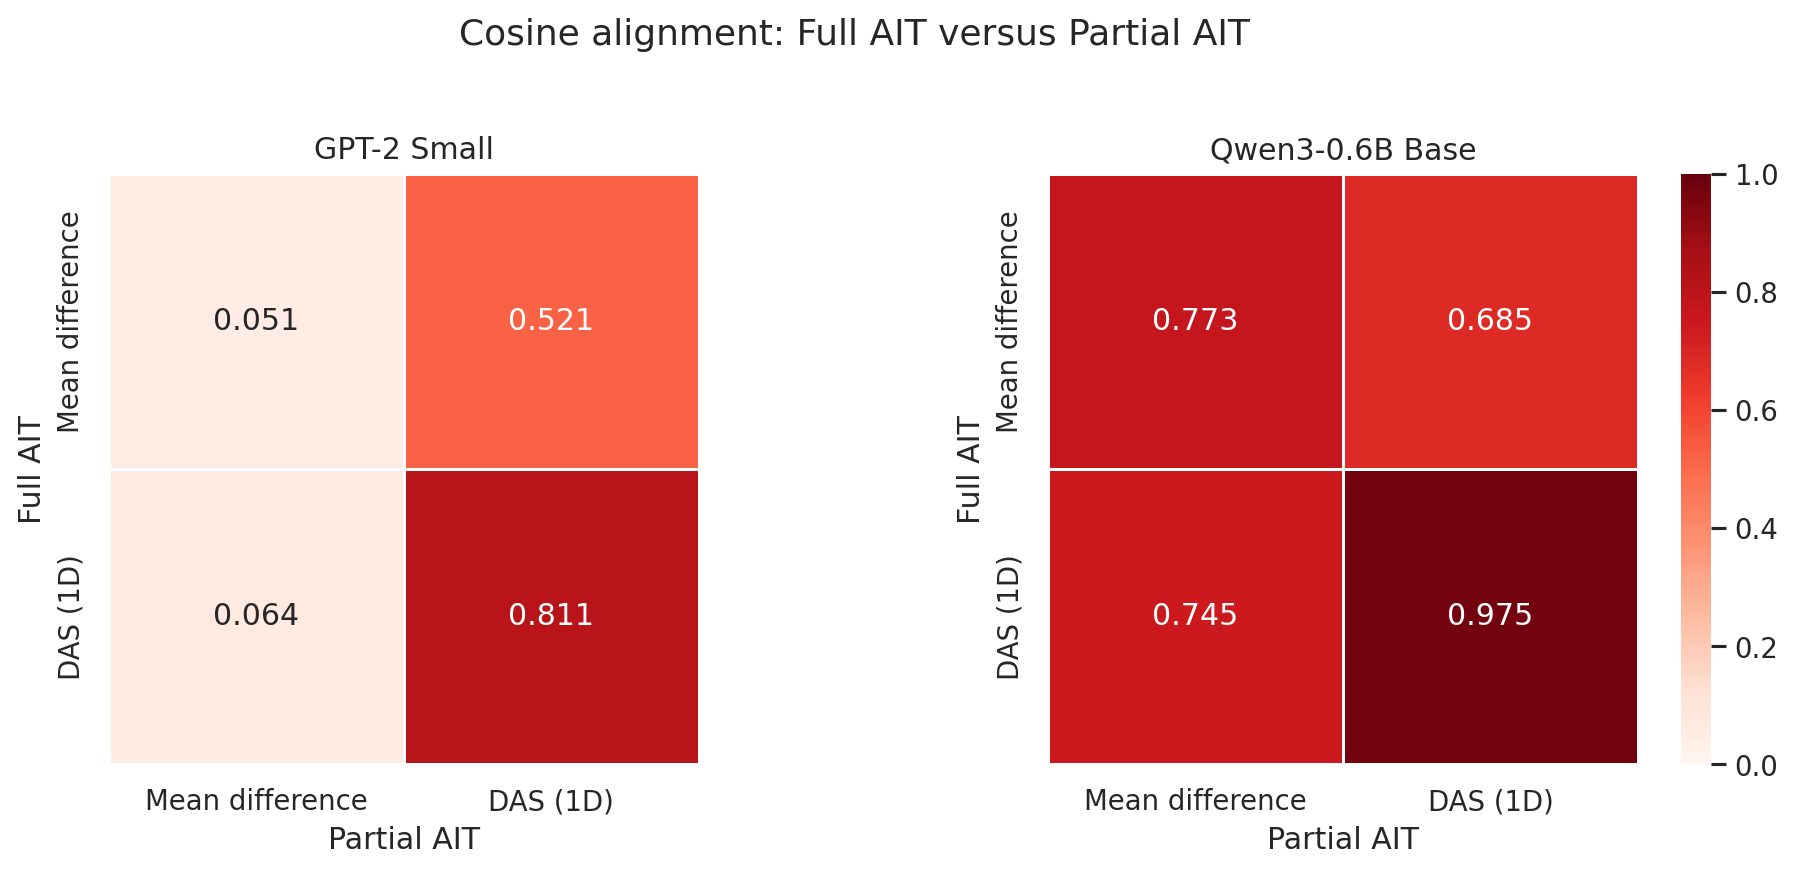

In [6]:
from IPython.display import Image

from sentiment_geometry.reporting import plot_pairwise_absolute_direction_alignment

figure_path = plot_pairwise_absolute_direction_alignment(
    absolute_cosines,
    figure_dir=RUN_LAYOUT.figures_dir,
    model_names=MODEL_ORDER,
    methods=METHOD_ORDER,
    row_label="Full AIT",
    column_label="Partial AIT",
)
RunArtifactStore(RUN_LAYOUT.results_dir).write_rows(
    "figure_manifest.csv", [{"figure": figure_path.name, "path": str(figure_path)}]
)
display(Image(filename=str(figure_path)))

## 6. Complete the exploration run

In [7]:
from datetime import datetime
from zoneinfo import ZoneInfo

completed_at = datetime.now(ZoneInfo(RUN_LAYOUT.timezone_name)).isoformat(timespec="minutes")
if RUN_ANALYSIS:
    RUN_LAYOUT.update_manifest(
        status="completed",
        metadata={
            "completed_at": completed_at,
            "selected_direction_rows": len(selections),
            "absolute_cosine_rows": len(absolute_cosines),
            "figure_count": 1,
        },
    )
    print("Completed run: ", RUN_LAYOUT.root)
else:
    print("Display-only refresh from:", RUN_LAYOUT.root)
print("Result tables: ", RUN_LAYOUT.results_dir)
print("Figure:        ", figure_path)
print("Manifest:      ", RUN_LAYOUT.manifest_path)

Display-only refresh from: /content/drive/MyDrive/sentiment-geometry/ait-training-scope-direction-alignment/runs/2026-10-01_02-44_CDT
Result tables:  /content/drive/MyDrive/sentiment-geometry/ait-training-scope-direction-alignment/runs/2026-10-01_02-44_CDT/results
Figure:         /content/drive/MyDrive/sentiment-geometry/ait-training-scope-direction-alignment/runs/2026-10-01_02-44_CDT/figures/absolute_cosine_full-ait_vs_partial-ait.png
Manifest:       /content/drive/MyDrive/sentiment-geometry/ait-training-scope-direction-alignment/runs/2026-10-01_02-44_CDT/run_manifest.json


## Interpretation guide

- Cosine alignment near `1` means strong axis alignment between the full- and partial-AIT directions, regardless of sign.
- Cosine alignment near `0` means near-orthogonality in the model's residual-stream coordinate system.

These results describe representational geometry only. High alignment does not establish causal equivalence, shared computation, or interchangeable interventions.